# NovaTech — Parte 2: Queries de verificación y análisis

Con el dataset ya poblado (`02_generate_data.ipynb`), aquí ejecuto las queries analíticas: ingresos y margen por categoría, segmentación de clientes, satisfacción y detección de incidencias.

In [1]:
import os
import matplotlib.pyplot as plt
from pathlib import Path
from dotenv import load_dotenv, find_dotenv
from google.cloud import bigquery
from google.oauth2 import service_account

dotenv_path = find_dotenv()
load_dotenv(dotenv_path)
PROJECT_ROOT = Path(dotenv_path).parent if dotenv_path else Path.cwd()
PROJECT_ID = os.getenv("GCP_PROJECT_ID")
DATASET_ID = os.getenv("BQ_DATASET_ID", "novatech")
CREDENTIALS_PATH = os.getenv("GOOGLE_APPLICATION_CREDENTIALS")

credentials = service_account.Credentials.from_service_account_file(PROJECT_ROOT / CREDENTIALS_PATH)
client = bigquery.Client(project=PROJECT_ID, credentials=credentials)

def run(sql):
    return client.query(sql).to_dataframe()

T = lambda name: f"`{PROJECT_ID}.{DATASET_ID}.{name}`"
print(f"Conectado a {PROJECT_ID}.{DATASET_ID}")

c:\Users\Usuario\AppData\Local\Programs\Python\Python310\lib\site-packages\google\api_core\_python_version_support.py:254: FutureWarning: You are using a Python version (3.10.11) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


Conectado a proyecto-507914.novatech


c:\Users\Usuario\AppData\Local\Programs\Python\Python310\lib\site-packages\google\api_core\_python_version_support.py:254: FutureWarning: You are using a Python version (3.10.11) which Google will stop supporting in new releases of google.cloud.bigquery once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.bigquery past that date.
  warnings.warn(message, FutureWarning)


## Estilo de los gráficos

Defino aquí los colores y el estilo para no repetirlo en cada gráfico: un azul para barras y líneas, gris para ejes y rejilla.

In [2]:
COLOR_BLUE = "#2a78d6"
COLOR_ORANGE = "#eb6834"
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"

def style_ax(ax, title, ylabel=""):
    ax.set_title(title, color=INK_PRIMARY, fontsize=12, fontweight="bold", loc="left", pad=12)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.spines["bottom"].set_color(GRIDLINE)
    ax.tick_params(colors=INK_MUTED, length=0)
    ax.yaxis.grid(True, color=GRIDLINE, linewidth=0.8)
    ax.set_axisbelow(True)
    if ylabel:
        ax.set_ylabel(ylabel, color=INK_SECONDARY, fontsize=9)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_color(INK_SECONDARY)

## 1. Ingresos totales y evolución mensual

In [3]:
q_revenue_monthly = f"""
SELECT
  FORMAT_TIMESTAMP('%Y-%m', o.order_date) AS month,
  ROUND(SUM(oi.quantity * oi.unit_price), 2) AS revenue,
  COUNT(DISTINCT o.order_id) AS n_orders
FROM {T('orders')} o
JOIN {T('order_items')} oi ON oi.order_id = o.order_id
WHERE o.status != 'cancelled'
GROUP BY month
ORDER BY month
"""
df_revenue_monthly = run(q_revenue_monthly)
df_revenue_monthly

c:\Users\Usuario\AppData\Local\Programs\Python\Python310\lib\site-packages\google\cloud\bigquery\table.py:2130: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,month,revenue,n_orders
0,2024-01,706179.49,147
1,2024-02,832201.24,154
2,2024-03,760134.47,159
3,2024-04,667142.80,145
4,2024-05,769261.77,161
5,2024-06,777899.41,138
6,2024-07,681008.87,143
7,2024-08,823961.84,157
8,2024-09,780558.33,168
9,2024-10,766072.29,164


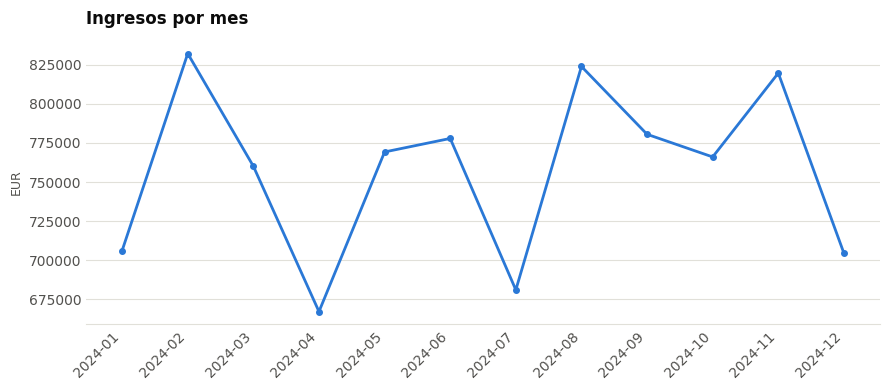

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(df_revenue_monthly["month"], df_revenue_monthly["revenue"], color=COLOR_BLUE, linewidth=2, marker="o", markersize=4)
style_ax(ax, "Ingresos por mes", "EUR")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 2. Ingresos, coste y margen por categoría



In [5]:
q_margin_category = f"""
SELECT
  c.name AS category,
  ROUND(SUM(oi.quantity * oi.unit_price), 2) AS revenue,
  ROUND(SUM(oi.quantity * oi.unit_cost), 2) AS cost,
  ROUND(SUM(oi.quantity * (oi.unit_price - oi.unit_cost)), 2) AS margin,
  ROUND(100 * SUM(oi.quantity * (oi.unit_price - oi.unit_cost)) / SUM(oi.quantity * oi.unit_price), 1) AS margin_pct
FROM {T('order_items')} oi
JOIN {T('products')} p ON p.product_id = oi.product_id
JOIN {T('categories')} c ON c.category_id = p.category_id
JOIN {T('orders')} o ON o.order_id = oi.order_id
WHERE o.status != 'cancelled'
GROUP BY category
ORDER BY revenue DESC
"""
df_margin_category = run(q_margin_category)
df_margin_category

c:\Users\Usuario\AppData\Local\Programs\Python\Python310\lib\site-packages\google\cloud\bigquery\table.py:2130: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,category,revenue,cost,margin,margin_pct
0,Audio,1828106.75,943846.18,884260.57,48.4
1,Gaming,1335533.45,538783.84,796749.61,59.7
2,Tablets,1299165.24,674394.67,624770.57,48.1
3,Accesorios,1222547.82,496383.59,726164.23,59.4
4,Wearables,1139123.67,522375.65,616748.02,54.1
5,Laptops,894255.36,451452.70,442802.66,49.5
6,Fotografia,827976.90,412840.06,415136.84,50.1
7,Smartphones,541918.26,263260.73,278657.53,51.4


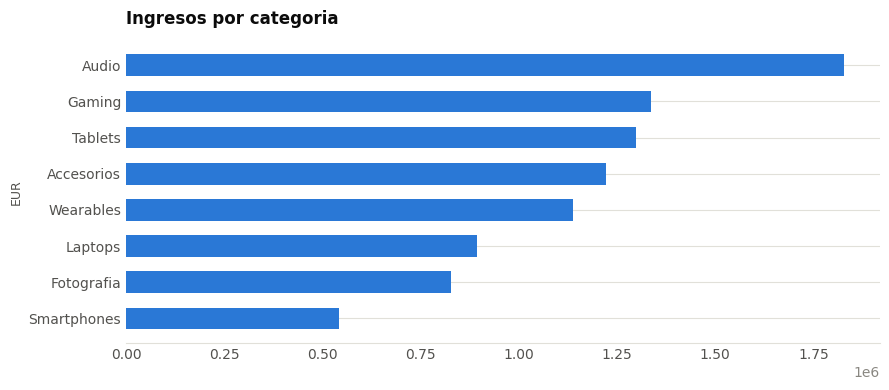

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
order = df_margin_category.sort_values("revenue", ascending=True)
ax.barh(order["category"], order["revenue"], color=COLOR_BLUE, height=0.6)
style_ax(ax, "Ingresos por categoria", "EUR")
plt.tight_layout()
plt.show()

## 3. Top 10 productos más vendidos (unidades e ingresos)

In [7]:
q_top_products = f"""
SELECT
  p.name AS product,
  c.name AS category,
  SUM(oi.quantity) AS units_sold,
  ROUND(SUM(oi.quantity * oi.unit_price), 2) AS revenue
FROM {T('order_items')} oi
JOIN {T('products')} p ON p.product_id = oi.product_id
JOIN {T('categories')} c ON c.category_id = p.category_id
JOIN {T('orders')} o ON o.order_id = oi.order_id
WHERE o.status != 'cancelled'
GROUP BY product, category
ORDER BY revenue DESC
LIMIT 10
"""
run(q_top_products)

c:\Users\Usuario\AppData\Local\Programs\Python\Python310\lib\site-packages\google\cloud\bigquery\table.py:2130: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,product,category,units_sold,revenue
0,Kortex Controller X,Gaming,340,401670.00
1,Nyra Pad Pro,Gaming,147,349583.64
2,Drakon Hub 2,Accesorios,161,327541.62
3,Vantix Console 2,Gaming,137,314590.36
4,Nyra Band Max,Wearables,159,311258.40
5,Orbeon Tone Lite,Audio,155,294267.50
6,Orbeon Cam Lite,Fotografia,115,279359.15
7,Ecliptic Band Pro,Wearables,152,278892.64
8,Vantix Charger Max,Accesorios,137,237978.59
9,Kortex Tab 2,Tablets,134,225315.64


## 4. Segmentación de clientes — por país y por canal de adquisición

In [8]:
q_by_country = f"""
SELECT
  cu.country,
  COUNT(DISTINCT cu.customer_id) AS n_customers,
  COUNT(DISTINCT o.order_id) AS n_orders,
  ROUND(IFNULL(SUM(oi.quantity * oi.unit_price), 0), 2) AS revenue
FROM {T('customers')} cu
LEFT JOIN {T('orders')} o ON o.customer_id = cu.customer_id AND o.status != 'cancelled'
LEFT JOIN {T('order_items')} oi ON oi.order_id = o.order_id
GROUP BY cu.country
ORDER BY revenue DESC
"""
run(q_by_country)

c:\Users\Usuario\AppData\Local\Programs\Python\Python310\lib\site-packages\google\cloud\bigquery\table.py:2130: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,country,n_customers,n_orders,revenue
0,Spain,186,661,3253028.84
1,Germany,92,325,1565752.97
2,France,77,317,1560755.22
3,Italy,57,219,1081423.96
4,Portugal,47,170,870430.97
5,Netherlands,41,162,757235.49


In [9]:
q_by_channel = f"""
SELECT
  cu.acquisition_channel,
  COUNT(DISTINCT cu.customer_id) AS n_customers,
  ROUND(IFNULL(SUM(oi.quantity * oi.unit_price), 0), 2) AS revenue,
  ROUND(IFNULL(SUM(oi.quantity * oi.unit_price), 0) / COUNT(DISTINCT cu.customer_id), 2) AS revenue_per_customer
FROM {T('customers')} cu
LEFT JOIN {T('orders')} o ON o.customer_id = cu.customer_id AND o.status != 'cancelled'
LEFT JOIN {T('order_items')} oi ON oi.order_id = o.order_id
GROUP BY cu.acquisition_channel
ORDER BY revenue DESC
"""
run(q_by_channel)

c:\Users\Usuario\AppData\Local\Programs\Python\Python310\lib\site-packages\google\cloud\bigquery\table.py:2130: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,acquisition_channel,n_customers,revenue,revenue_per_customer
0,organic,149,2820392.02,18928.81
1,paid_ads,134,2438539.59,18198.06
2,social_media,87,1616021.93,18574.96
3,referral,81,1429637.59,17649.85
4,email_marketing,49,784036.32,16000.74


## 5. Top 10 clientes por gasto (LTV)

In [10]:
q_top_customers = f"""
SELECT
  cu.customer_id,
  CONCAT(cu.first_name, ' ', cu.last_name) AS customer,
  cu.country,
  ROUND(SUM(oi.quantity * oi.unit_price), 2) AS total_spent,
  COUNT(DISTINCT o.order_id) AS n_orders
FROM {T('customers')} cu
JOIN {T('orders')} o ON o.customer_id = cu.customer_id AND o.status != 'cancelled'
JOIN {T('order_items')} oi ON oi.order_id = o.order_id
GROUP BY cu.customer_id, customer, cu.country
ORDER BY total_spent DESC
LIMIT 10
"""
run(q_top_customers)

c:\Users\Usuario\AppData\Local\Programs\Python\Python310\lib\site-packages\google\cloud\bigquery\table.py:2130: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,customer_id,customer,country,total_spent,n_orders
0,359,David Irwin,Spain,59359.53,10
1,146,Kelly Thornton,France,58421.85,9
2,252,Nathaniel Hughes,Italy,55044.40,7
3,72,Angela Lee,France,52934.46,8
4,176,Karen Perez,Spain,51411.91,6
5,118,Kenneth Ward,Germany,50474.09,8
6,393,Gabriella Abbott,Italy,49970.75,7
7,66,Mark Johnson,Spain,49087.30,8
8,69,Aaron Frost,France,48533.65,8
9,244,Robert Rhodes,Italy,48354.12,8


## 6. Satisfacción — valoración media por categoría

In [11]:
q_rating_category = f"""
SELECT
  c.name AS category,
  ROUND(AVG(r.rating), 2) AS avg_rating,
  COUNT(*) AS n_reviews
FROM {T('reviews')} r
JOIN {T('products')} p ON p.product_id = r.product_id
JOIN {T('categories')} c ON c.category_id = p.category_id
GROUP BY category
ORDER BY avg_rating DESC
"""
df_rating_category = run(q_rating_category)
df_rating_category

c:\Users\Usuario\AppData\Local\Programs\Python\Python310\lib\site-packages\google\cloud\bigquery\table.py:2130: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,category,avg_rating,n_reviews
0,Fotografia,4.03,182
1,Audio,4.00,233
2,Tablets,3.98,241
3,Laptops,3.98,157
4,Wearables,3.96,169
5,Smartphones,3.95,77
6,Accesorios,3.88,151
7,Gaming,3.82,131


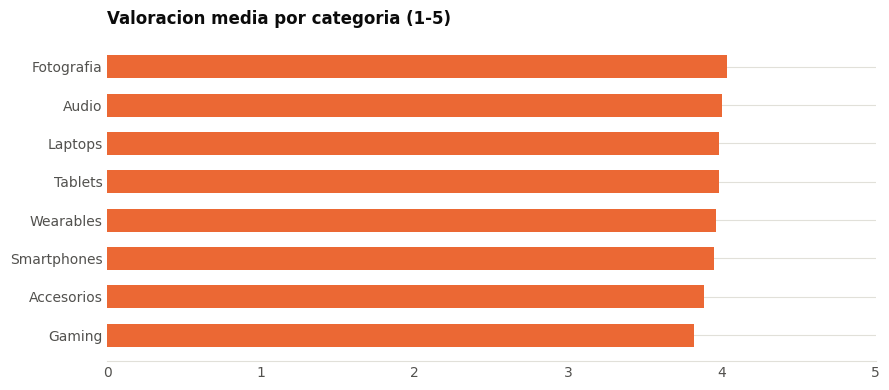

In [12]:
fig, ax = plt.subplots(figsize=(9, 4))
order = df_rating_category.sort_values("avg_rating", ascending=True)
ax.barh(order["category"], order["avg_rating"], color=COLOR_ORANGE, height=0.6)
ax.set_xlim(0, 5)
style_ax(ax, "Valoracion media por categoria (1-5)")
plt.tight_layout()
plt.show()

## 7. Incidencias — pagos

In [13]:
q_payment_incidents = f"""
SELECT
  status,
  COUNT(*) AS n_payments,
  ROUND(100 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS pct
FROM {T('payments')}
GROUP BY status
ORDER BY n_payments DESC
"""
run(q_payment_incidents)

c:\Users\Usuario\AppData\Local\Programs\Python\Python310\lib\site-packages\google\cloud\bigquery\table.py:2130: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,status,n_payments,pct
0,completed,1828,87.4
1,failed,237,11.3
2,refunded,26,1.2


## 8. Incidencias — envíos: tiempo medio de entrega por transportista

In [14]:
q_shipping_time = f"""
SELECT
  carrier,
  COUNT(*) AS n_shipments,
  ROUND(AVG(TIMESTAMP_DIFF(delivered_date, shipped_date, HOUR)) / 24.0, 2) AS avg_days_to_deliver
FROM {T('shipments')}
WHERE status = 'delivered'
GROUP BY carrier
ORDER BY avg_days_to_deliver
"""
run(q_shipping_time)

c:\Users\Usuario\AppData\Local\Programs\Python\Python310\lib\site-packages\google\cloud\bigquery\table.py:2130: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,carrier,n_shipments,avg_days_to_deliver
0,SEUR,260,3.27
1,Correos Express,255,3.53
2,UPS,263,3.53
3,DHL,269,3.57
4,GLS,242,3.67


## 9. Estado del embudo de pedidos

In [15]:
q_order_funnel = f"""
SELECT
  status,
  COUNT(*) AS n_orders,
  ROUND(100 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS pct
FROM {T('orders')}
GROUP BY status
ORDER BY n_orders DESC
"""
run(q_order_funnel)

c:\Users\Usuario\AppData\Local\Programs\Python\Python310\lib\site-packages\google\cloud\bigquery\table.py:2130: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,status,n_orders,pct
0,delivered,1289,64.5
1,shipped,244,12.2
2,processing,171,8.6
3,pending,150,7.5
4,cancelled,146,7.3


## Conclusión

Con esto cubro los puntos que pedía el enunciado: clientes/productos, ingresos y márgenes por categoría, segmentación geográfica y por canal, satisfacción, y el control operativo de incidencias (pagos y envíos). Todo se resuelve con un JOIN directo entre 2 y 4 tablas, sin campos derivados guardados de más, así que el modelo en 3NF aguanta bien la parte analítica.